In [1]:
import os
os.environ["PYOPENGL_PLATFORM"] = "egl"
import pyrender
import cv2
import glob
import json
import time
import trimesh
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=3)
from scipy.spatial.transform import Rotation as R
from bpc.inference.utils.camera_utils import load_camera_params
from bpc.inference.process_pose import PoseEstimator, PoseEstimatorParams
from bpc.utils.data_utils import Capture, render_mask
import bpc.utils.data_utils as du
import importlib


ImportError: cannot import name 'GDRNet' from 'bpc.pose.models.gdr_net' (/home/vedantmehra/Desktop/my_bpc_baseline/bpc/pose/models/gdr_net.py)

./datasets/ipd_models/models/obj_000000.ply
Loading camera parameters from: ./datasets/ipd_val/val/000007/scene_camera_cam3.json
['./datasets/ipd_val/val/000007/rgb_cam1/000003.png', './datasets/ipd_val/val/000007/rgb_cam2/000003.png', './datasets/ipd_val/val/000007/rgb_cam3/000003.png']
no.of images in Capture:  3
Camera cam1 was called
0
0
0
0
18
18  skipped
18
18  skipped
18
18  skipped
18
18  skipped
18
18  skipped
gt_poses
 [array([[   -0.13349,    0.058248,    -0.98934,      373.04],
       [    0.99051,   -0.025157,    -0.13513,      265.09],
       [  -0.032759,    -0.99799,   -0.054337,      1734.6],
       [          0,           0,           0,           1]]), array([[   0.041795,     0.90173,    -0.43027,      28.142],
       [  0.0034455,    -0.43077,    -0.90245,      186.92],
       [   -0.99912,    0.036235,   -0.021111,      1738.9],
       [          0,           0,           0,           1]]), array([[   0.043585,      0.9249,     -0.3777,      235.19],
       [  -0.

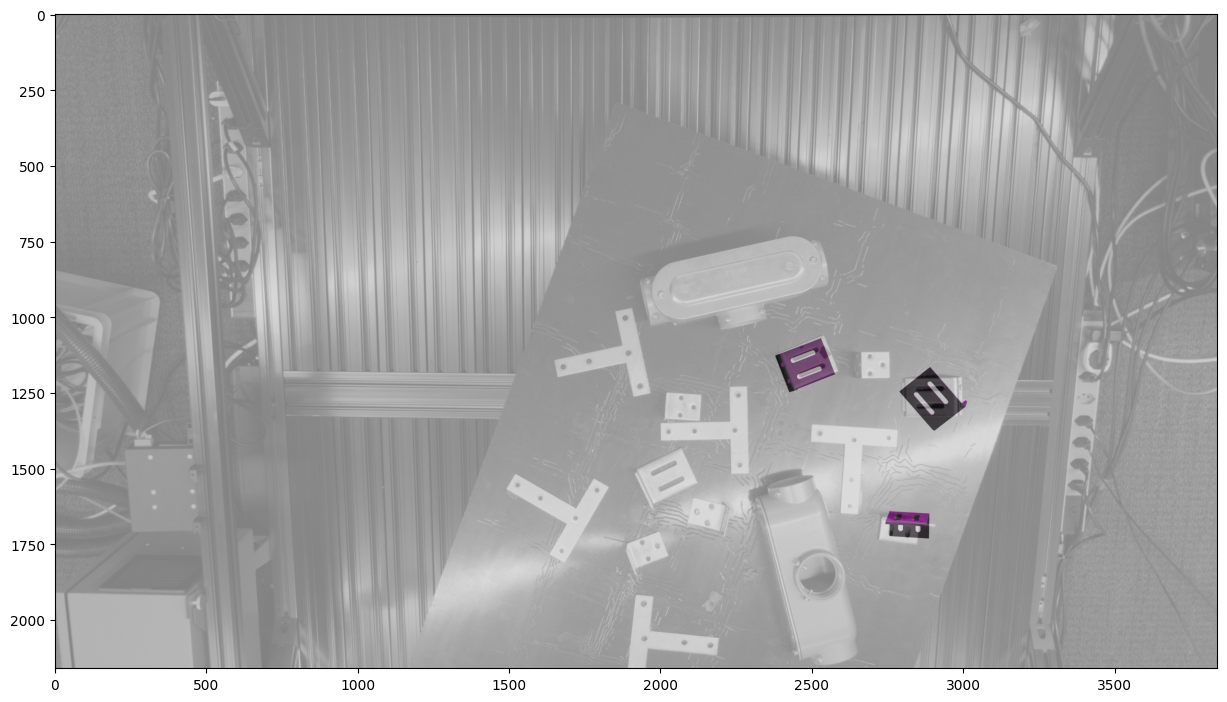

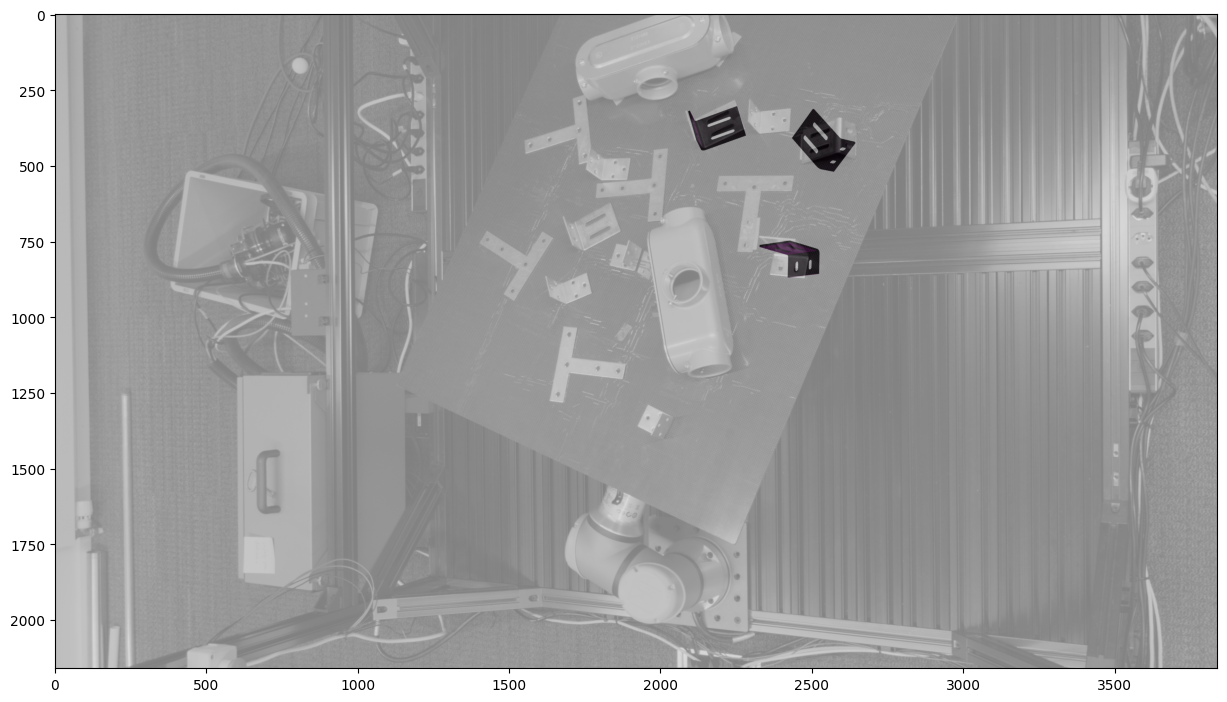

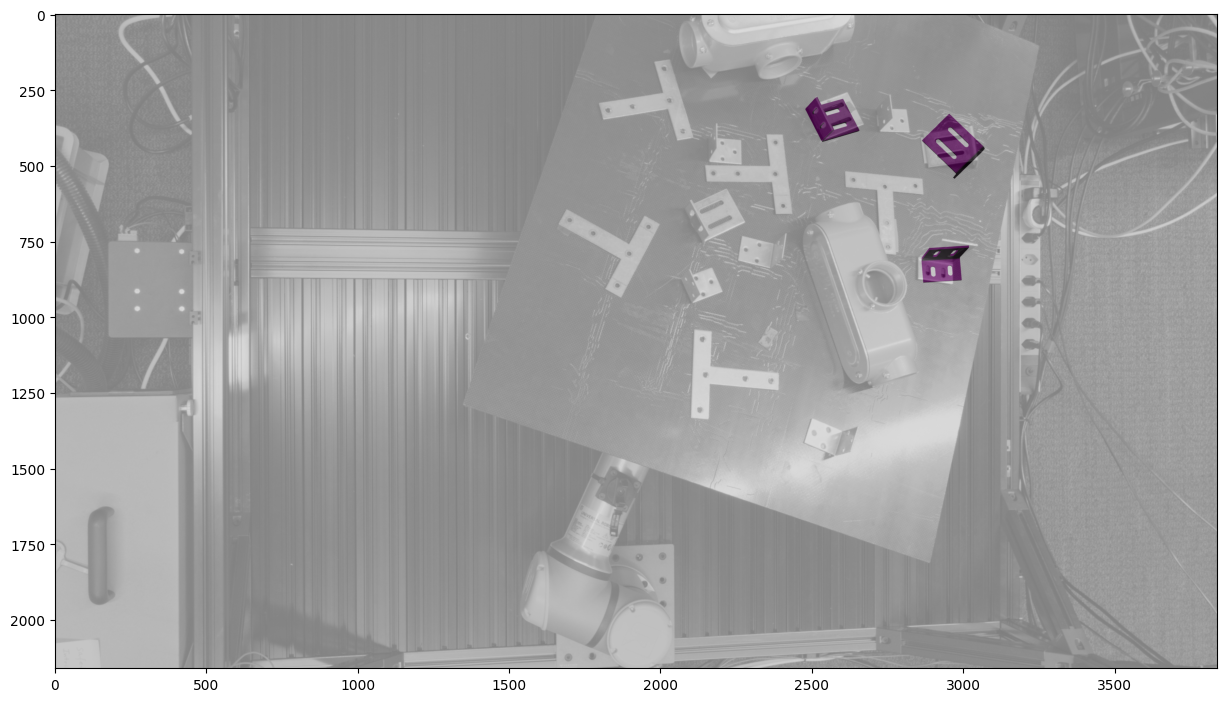

In [2]:
# scene_dir = "./datasets/ipd_bop_data_jan25_1/train_pbr/000000/"
# models_dir = './datasets/ipd_bop_data_jan25_1/models_eval/'
scene_dir = "./datasets/ipd_val/val/000007/" # must contain 0th object
models_dir = './datasets/ipd_models/models/'
cam_ids = ["cam1", "cam2", "cam3"]
image_id = 3
obj_id = 0
obj_id_path = str(1000000+obj_id)[1:]
ply_file = os.path.join(models_dir, f"obj_{obj_id_path}.ply")
print(ply_file)
obj = trimesh.load(ply_file)
yolo_model_path = f'yolo/models/detection/obj_{obj_id}/yolo11-detection-obj_{obj_id}.pt'
# yolo_model_path = f'models/detection/obj_{obj_id}/yolo11-detection-obj_{obj_id}.pt'

# pose_model_path = f'models/rot_models/rot_{obj_id}.pth'
pose_model_path = f'/home/vedantmehra/bpc_baseline/bpc/pose/checkpoints/obj_0/best_model.pth'

pose_params = PoseEstimatorParams(yolo_model_path=yolo_model_path,
                                  pose_model_path=pose_model_path, 
                                  yolo_conf_thresh=0.01,model = "simple_pose_net")
pose_estimator = PoseEstimator(pose_params)
t = time.time()
capture = Capture.from_dir(scene_dir, cam_ids, image_id, obj_id) #object of class Capture

# yolo detections
detections = pose_estimator._detect(capture) 
print("yolo\n",detections)

# objects of class PosePrediction with properties of everything like bboxes and capture etc....
pose_predictions = pose_estimator._match(capture, detections)

# get pose after triangulation
pose_estimator._estimate_rotation(pose_predictions)
print(time.time() - t)
print(pose_predictions[0].pose)

for idx in range(len(capture.Ks)):
    plt.figure(figsize=(15, 15))
    plt.imshow(capture.images[idx])
    a, b = render_mask(obj, capture.Ks[idx], (capture.RTs[idx]), capture.images[0].shape[:2][::-1], [x.pose for x in pose_predictions])
    plt.imshow(a, alpha=0.5)
    plt.show()

./datasets/ipd_models/models/obj_000000.ply
Loading camera parameters from: ./datasets/ipd_val/val/000007/scene_camera_cam3.json
['./datasets/ipd_val/val/000007/rgb_cam1/000003.png', './datasets/ipd_val/val/000007/rgb_cam2/000003.png', './datasets/ipd_val/val/000007/rgb_cam3/000003.png']
no.of images in Capture:  3
Camera cam1 was called
0
0
0
0
18
18  skipped
18
18  skipped
18
18  skipped
18
18  skipped
18
18  skipped
gt_poses
 [array([[   -0.13349,    0.058248,    -0.98934,      373.04],
       [    0.99051,   -0.025157,    -0.13513,      265.09],
       [  -0.032759,    -0.99799,   -0.054337,      1734.6],
       [          0,           0,           0,           1]]), array([[   0.041795,     0.90173,    -0.43027,      28.142],
       [  0.0034455,    -0.43077,    -0.90245,      186.92],
       [   -0.99912,    0.036235,   -0.021111,      1738.9],
       [          0,           0,           0,           1]]), array([[   0.043585,      0.9249,     -0.3777,      235.19],
       [  -0.

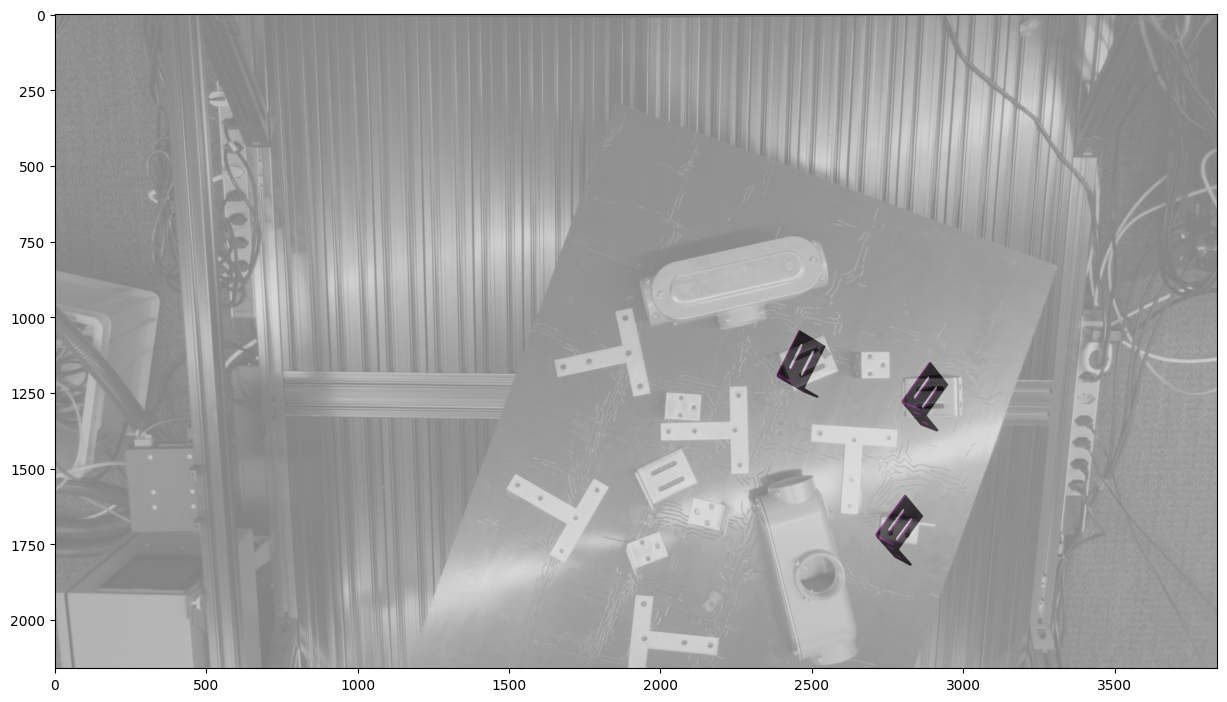

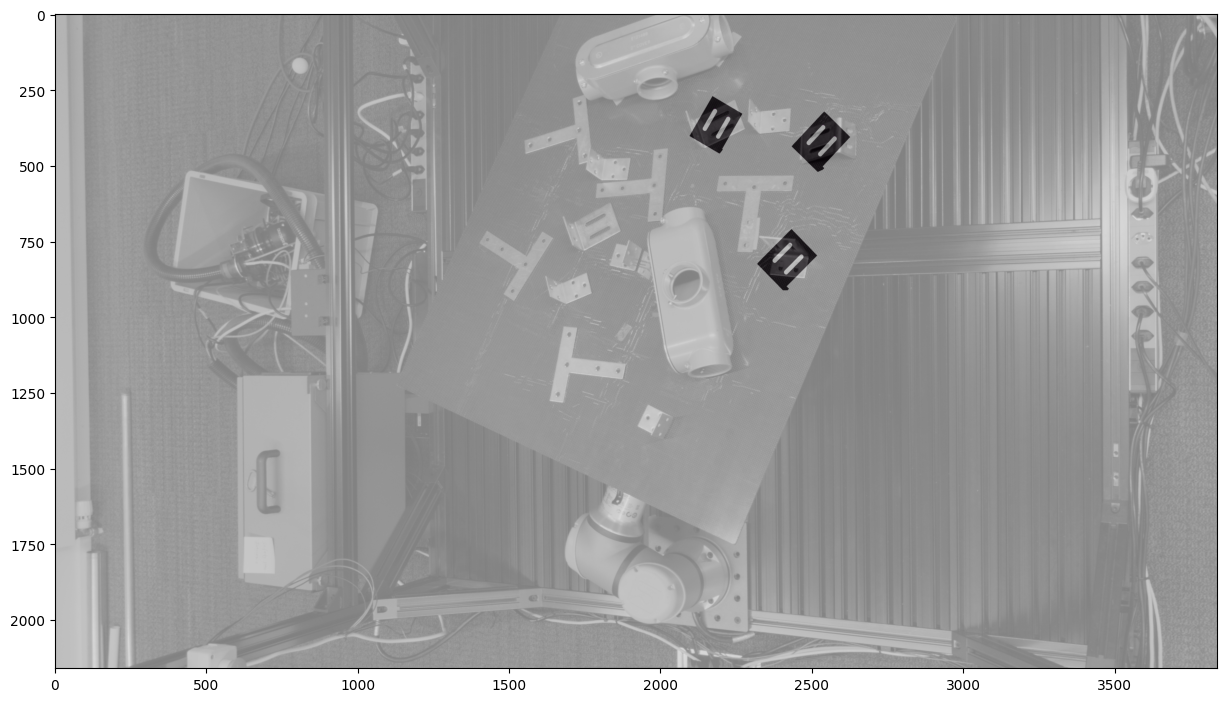

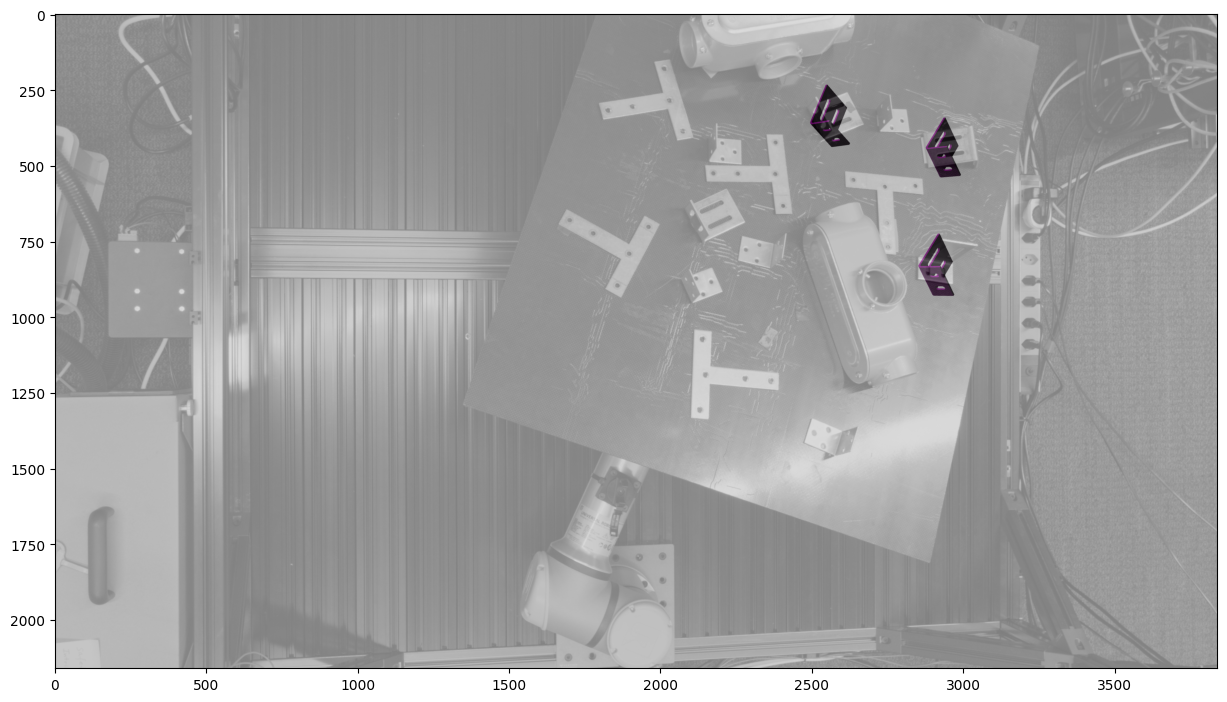

In [3]:
# scene_dir = "./datasets/ipd_bop_data_jan25_1/train_pbr/000000/"
# models_dir = './datasets/ipd_bop_data_jan25_1/models_eval/'
scene_dir = "./datasets/ipd_val/val/000007/" # must contain 0th object
models_dir = './datasets/ipd_models/models/'
cam_ids = ["cam1", "cam2", "cam3"]
image_id = 3
obj_id = 0
obj_id_path = str(1000000+obj_id)[1:]
ply_file = os.path.join(models_dir, f"obj_{obj_id_path}.ply")
print(ply_file)
obj = trimesh.load(ply_file)
yolo_model_path = f'yolo/models/detection/obj_{obj_id}/yolo11-detection-obj_{obj_id}.pt'
# yolo_model_path = f'models/detection/obj_{obj_id}/yolo11-detection-obj_{obj_id}.pt'

# pose_model_path = f'models/rot_models/rot_{obj_id}.pth'
pose_model_path = f'bpc/pose/checkpoints_gdr/obj_{obj_id}/best_model.pth'

pose_params = PoseEstimatorParams(yolo_model_path=yolo_model_path,
                                  pose_model_path=pose_model_path, 
                                  yolo_conf_thresh=0.01, model = "gdr_net")
pose_estimator = PoseEstimator(pose_params)
t = time.time()
capture = Capture.from_dir(scene_dir, cam_ids, image_id, obj_id) #object of class Capture

# yolo detections
detections = pose_estimator._detect(capture) 
print("yolo\n",detections)

# objects of class PosePrediction with properties of everything like bboxes and capture etc....
pose_predictions = pose_estimator._match(capture, detections)

# get pose after triangulation
pose_estimator._estimate_rotation(pose_predictions)
print(time.time() - t)
print(pose_predictions[0].pose)

for idx in range(len(capture.Ks)):
    plt.figure(figsize=(15, 15))
    plt.imshow(capture.images[idx])
    a, b = render_mask(obj, capture.Ks[idx], (capture.RTs[idx]), capture.images[0].shape[:2][::-1], [x.pose for x in pose_predictions])
    plt.imshow(a, alpha=0.5)
    plt.show()